In [ ]:
!pip -q install gdown

import re
import numpy as np
import pandas as pd
import gdown

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import RidgeCV, LassoCV

# Initial inspection and loads

In [ ]:
# Read Parquet
gdown.download(
    "https://drive.google.com/uc?id=1v59vFPEgfXPvCbp7wTnBiqtfq5X5BYBi",
    "data.parquet",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1v59vFPEgfXPvCbp7wTnBiqtfq5X5BYBi
To: /content/data.parquet
100%|██████████| 43.4M/43.4M [00:00<00:00, 62.4MB/s]


'data.parquet'

In [ ]:
# filter for 2025 only for the initial explanations of valuations investigation
df = pd.read_parquet("data.parquet")
df = df[df["ROLL_YEAR"] == 2025].copy()

In [ ]:
# Initial inspect
pd.set_option("display.max_columns", None)
display(df.head(5))

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,ASSESSMENT_CLASS_DESCRIPTION,RE_ASSESSED_VALUE,NR_ASSESSED_VALUE,FL_ASSESSED_VALUE,COMM_CODE,COMM_NAME,YEAR_OF_CONSTRUCTION,LAND_USE_DESIGNATION,PROPERTY_TYPE,LAND_SIZE_SM,LAND_SIZE_SF,LAND_SIZE_AC,SUB_PROPERTY_USE,MULTIPOLYGON,CPID,VALUE_PER_SM
9,2025,3002102,8825 52 ST NE,876500.0,RE,Residential,876500.0,NaN,NaN,SAD,SADDLE RIDGE,2003.0,DC,LI,17740.4,190962.0,4.38,RAWDL,"MULTIPOLYGON (((-113.9598606 51.1306945, -113....",250264641,49.407003
22,2025,3003506,5029 84 AV NE,737000.0,RE,Residential,737000.0,NaN,NaN,SAD,SADDLE RIDGE,1968.0,S-FUD,LI,19693.0,211980.0,4.87,RE0100,"MULTIPOLYGON (((-113.9613164 51.128774, -113.9...",310264647,37.424466
38,2025,4001301,655 SADDLECREEK WY NE,676500.0,RE,Residential,676500.0,NaN,NaN,SAD,SADDLE RIDGE,2000.0,R-G,LI,561.5,6044.0,0.14,RE0110,"MULTIPOLYGON (((-113.9544399 51.1253565, -113....",920574332,1204.808549
45,2025,4001509,647 SADDLECREEK WY NE,694000.0,RE,Residential,694000.0,NaN,NaN,SAD,SADDLE RIDGE,2000.0,R-G,LI,491.0,5285.0,0.12,RE0110,"MULTIPOLYGON (((-113.9546053 51.1253564, -113....",890574329,1413.441955
52,2025,4001905,631 SADDLECREEK WY NE,666000.0,RE,Residential,666000.0,NaN,NaN,SAD,SADDLE RIDGE,2000.0,R-G,LI,465.2,5007.0,0.11,RE0110,"MULTIPOLYGON (((-113.955267 51.125356, -113.95...",840574324,1431.642304


# Feature cleaning and engineering

In [ ]:
# Remove features which don't seem useful for ML analysis
df = df.drop(columns=["LAND_SIZE_SF", "LAND_SIZE_AC", "ASSESSMENT_CLASS_DESCRIPTION", "RE_ASSESSED_VALUE", "NR_ASSESSED_VALUE", "FL_ASSESSED_VALUE", "LAND_USE_DESIGNATION", "SUB_PROPERTY_USE", "COMM_NAME"])

In [ ]:
# Extract all lon/lat pairs from the polygon and take their average
def avg_center_point(wkt):
    if pd.isna(wkt):
        return pd.Series([None, None])

    coords = re.findall(r'(-?\d+\.\d+)\s+(-?\d+\.\d+)', str(wkt))
    if not coords:
        return pd.Series([None, None])

    lons = [float(x[0]) for x in coords]
    lats = [float(x[1]) for x in coords]

    return pd.Series([sum(lons) / len(lons), sum(lats) / len(lats)])

df[["center_longitude", "center_latitude"]] = df["MULTIPOLYGON"].apply(avg_center_point)

# Drop original multipolygon column too
df = df.drop(columns=["MULTIPOLYGON"])

In [ ]:
# Fill missing construction years with median based on community and assessment class

df["YEAR_BUILT_MISSING"] = df["YEAR_OF_CONSTRUCTION"].isna().astype(int)

df["YEAR_OF_CONSTRUCTION"] = (
    df.groupby(["COMM_CODE", "ASSESSMENT_CLASS"])["YEAR_OF_CONSTRUCTION"]
      .transform(lambda x: x.fillna(x.median()))
)

df["YEAR_OF_CONSTRUCTION"] = df["YEAR_OF_CONSTRUCTION"].fillna(
    df["YEAR_OF_CONSTRUCTION"].median()
)

# remove indicator
df = df.drop(columns=["YEAR_BUILT_MISSING"])

In [ ]:
df["AGE_OF_PROPERTY"] = 2025 - df["YEAR_OF_CONSTRUCTION"]

In [ ]:
# Engineer some more geographical features

# 1) Choose a city-centre point
# Approx downtown Calgary / central core
CALGARY_CENTRE_LAT = 51.0447
CALGARY_CENTRE_LON = -114.0719

# 2) Distance from centre (km)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df["DIST_FROM_CENTRE_KM"] = haversine_km(
    df["center_latitude"],
    df["center_longitude"],
    CALGARY_CENTRE_LAT,
    CALGARY_CENTRE_LON
)

# 3) Quadrant / central feature-
# Central radius in km
CENTRAL_RADIUS_KM = 3.0

def assign_area(lat, lon, dist_km, centre_lat=CALGARY_CENTRE_LAT, centre_lon=CALGARY_CENTRE_LON):
    if pd.isna(lat) or pd.isna(lon):
        return pd.NA

    if dist_km <= CENTRAL_RADIUS_KM:
        return "CENTRAL"

    if lat >= centre_lat and lon >= centre_lon:
        return "NE"
    elif lat >= centre_lat and lon < centre_lon:
        return "NW"
    elif lat < centre_lat and lon >= centre_lon:
        return "SE"
    else:
        return "SW"

df["CITY_AREA"] = df.apply(
    lambda row: assign_area(
        row["center_latitude"],
        row["center_longitude"],
        row["DIST_FROM_CENTRE_KM"]
    ),
    axis=1
)

# Make categorical
df["CITY_AREA"] = pd.Categorical(
    df["CITY_AREA"],
    categories=["CENTRAL", "NW", "NE", "SW", "SE"]
)

# Quick check
print(df["CITY_AREA"].value_counts(dropna=False))

CITY_AREA
NW         31634
SE         27909
NE         21323
SW         21294
CENTRAL    15452
Name: count, dtype: int64


In [ ]:
# Create an estimate of density
df["COMM_PROPERTY_COUNT"] = df.groupby("COMM_CODE")["ROLL_NUMBER"].transform("count")
df[["COMM_CODE", "COMM_PROPERTY_COUNT"]].drop_duplicates().sample(10)

,COMM_CODE,COMM_PROPERTY_COUNT
57174,WIN,317
59932,CAM,160
397634,CRM,229
10224,THO,632
221058,MAN,85
215498,ALT,633
237472,EAG,20
644232,MDH,47
421982,COU,304
375477,05D,4


# Create train, val, test datasets

In [ ]:
# First: 80% train, 20% temp
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42)

# Then split the 20% temp into half-half = 10% val, 10% test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))

Train size: 94089
Validation size: 11761
Test size: 11762


In [ ]:
# Create feature of value per SM for 10 nearest properties
# After train, val, test split to avoid leakage

coords = ["center_latitude", "center_longitude"]

nn = NearestNeighbors(n_neighbors=10, algorithm="ball_tree")
nn.fit(df_train[coords])

# Create feature for train
def knn_feature(df_source, df_target, nn_model, k=10):
    distances, indices = nn_model.kneighbors(df_target[coords], n_neighbors=k+1)

    # drop first neighbor (itself)
    indices = indices[:, 1:]

    values = df_source["VALUE_PER_SM"].values

    return np.median(values[indices], axis=1)

df_train["NEARBY_MEDIAN_VALUE_PER_SM"] = knn_feature(
    df_train, df_train, nn, k=10
)

# Create feature for val and test
df_val["NEARBY_MEDIAN_VALUE_PER_SM"] = knn_feature(
    df_train, df_val, nn, k=10
)

df_test["NEARBY_MEDIAN_VALUE_PER_SM"] = knn_feature(
    df_train, df_test, nn, k=10
)

# Final feature analysis and visuals

In [ ]:
# Numerical features
pd.set_option("display.float_format", "{:,.0f}".format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ROLL_YEAR,"117,612","2,025",0,"2,025","2,025","2,025","2,025","2,025"
ROLL_NUMBER,"117,612","182,141,768","137,853,792","3,002,102","86,004,356","200,526,221","202,277,424","903,001,303"
ASSESSED_VALUE,"117,612","819,582","7,449,316",70,"350,000","575,000","767,000","1,546,730,000"
YEAR_OF_CONSTRUCTION,"117,612","1,994",22,"1,893","1,979","2,000","2,011","2,024"
LAND_SIZE_SM,"117,612","4,377","56,000",0,377,550,"2,312","13,342,400"
VALUE_PER_SM,"117,612","1,287","8,746",0,115,"1,271","1,831","1,902,500"
center_longitude,"117,612",-114,0,-114,-114,-114,-114,-114
center_latitude,"117,612",51,0,51,51,51,51,51
AGE_OF_PROPERTY,"117,612",31,22,1,14,25,46,132
DIST_FROM_CENTRE_KM,"117,612",10,6,0,6,11,15,24


In [ ]:
# Categorical features
df.describe(include=["object", "string", "category"]).T

,count,unique,top,freq
ADDRESS,117612,116574,3025 SPILLER RD SE,138
ASSESSMENT_CLASS,117612,3,RE,112277
COMM_CODE,117612,306,BLN,4179
PROPERTY_TYPE,117612,3,LI,113999
CPID,117612,83338,96142195,231
CITY_AREA,117612,5,NW,31634


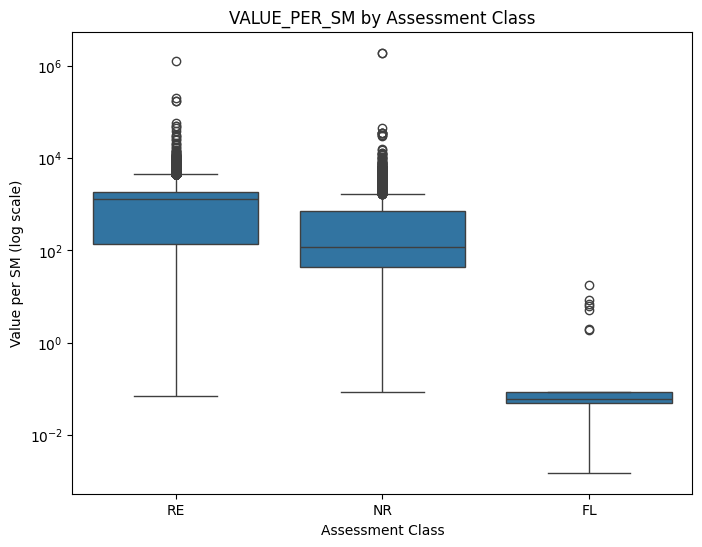

In [ ]:
# Explore value_per_sm dist by assessment class

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="ASSESSMENT_CLASS",
    y="VALUE_PER_SM"
)

plt.yscale("log")  # important for your data
plt.title("VALUE_PER_SM by Assessment Class")
plt.xlabel("Assessment Class")
plt.ylabel("Value per SM (log scale)")

plt.show()

In [ ]:
# Assessment class splits
summary = df.groupby("ASSESSMENT_CLASS", dropna=False).agg(
    count=("ASSESSMENT_CLASS", "size"),
    total_land_sm=("LAND_SIZE_SM", "sum")
).sort_values("count", ascending=False)

summary.style.format({
    "count": "{:,.0f}",
    "total_land_sm": "{:,.0f}"
})

,count,total_land_sm
ASSESSMENT_CLASS,,
RE,"112,277","341,102,001"
NR,"5,270","149,369,657"
FL,65,"24,320,297"


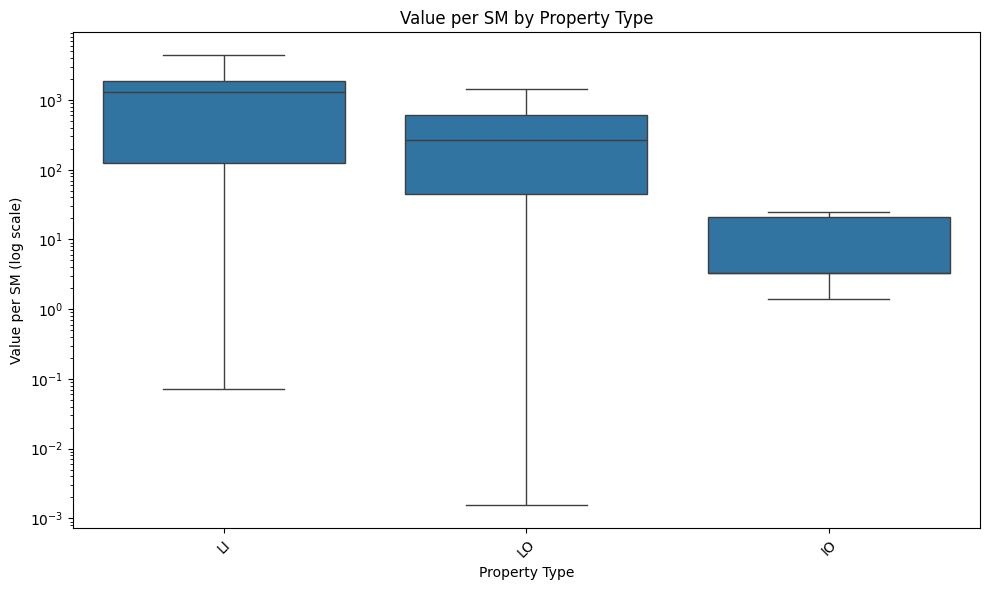

In [ ]:
# LI = land improvement LO = land only IO = improvement only value per SM

df_plot = df[
    df["PROPERTY_TYPE"].notna() &
    df["VALUE_PER_SM"].notna() &
    (df["VALUE_PER_SM"] > 0)
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x="PROPERTY_TYPE",
    y="VALUE_PER_SM",
    showfliers=False
)

plt.yscale("log")
plt.xlabel("Property Type")
plt.ylabel("Value per SM (log scale)")
plt.title("Value per SM by Property Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Land only, land improvement, improvement only
df["PROPERTY_TYPE"].value_counts()

,count
PROPERTY_TYPE,
LI,113999
LO,3599
IO,14


Investigated largest ones and they are legitimate - university, Chinook mall, hospitals, high rise apartment buildings etc. Smallest ones seem a bit suspect.

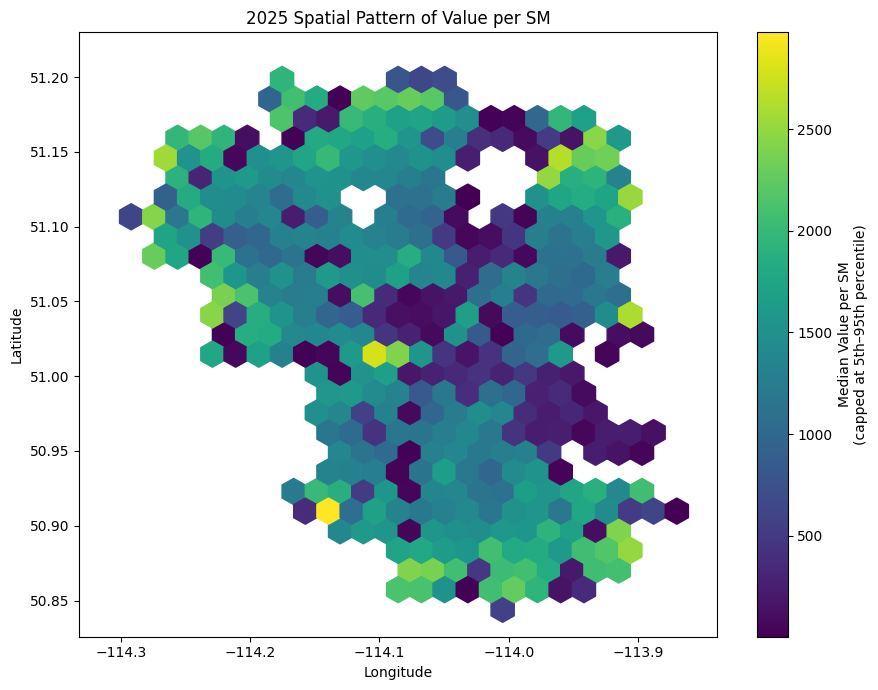

In [ ]:
# Map of value per sq m

df_plot = df[df["ROLL_YEAR"] == 2025].dropna(
    subset=["center_longitude", "center_latitude", "VALUE_PER_SM"]
).copy()

df_plot = df_plot[df_plot["VALUE_PER_SM"] > 0]

low = df_plot["VALUE_PER_SM"].quantile(0.05)
high = df_plot["VALUE_PER_SM"].quantile(0.95)
df_plot["VALUE_PER_SM_CAPPED"] = df_plot["VALUE_PER_SM"].clip(lower=low, upper=high)

plt.figure(figsize=(9, 7))

hb = plt.hexbin(
    df_plot["center_longitude"],
    df_plot["center_latitude"],
    C=df_plot["VALUE_PER_SM_CAPPED"],
    reduce_C_function=np.median,
    gridsize=25,
    mincnt=5
)

cbar = plt.colorbar(hb)
cbar.set_label("Median Value per SM\n(capped at 5th–95th percentile)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("2025 Spatial Pattern of Value per SM")
plt.tight_layout()
plt.show()

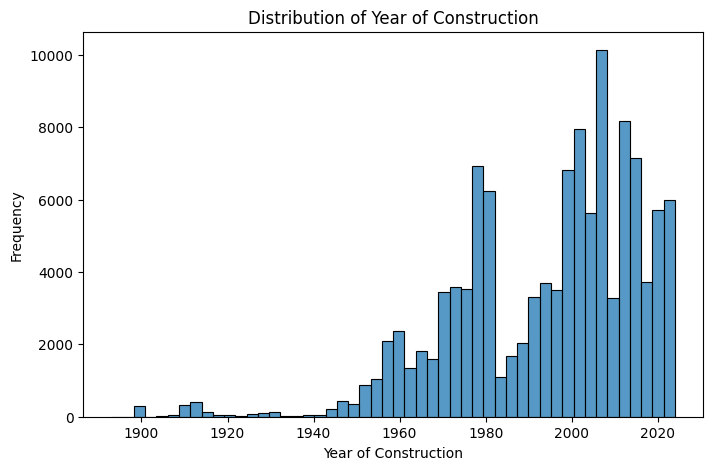

In [ ]:
# Hist of year of construction

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="YEAR_OF_CONSTRUCTION",
    bins=50
)

plt.xlabel("Year of Construction")
plt.ylabel("Frequency")
plt.title("Distribution of Year of Construction")
plt.show()

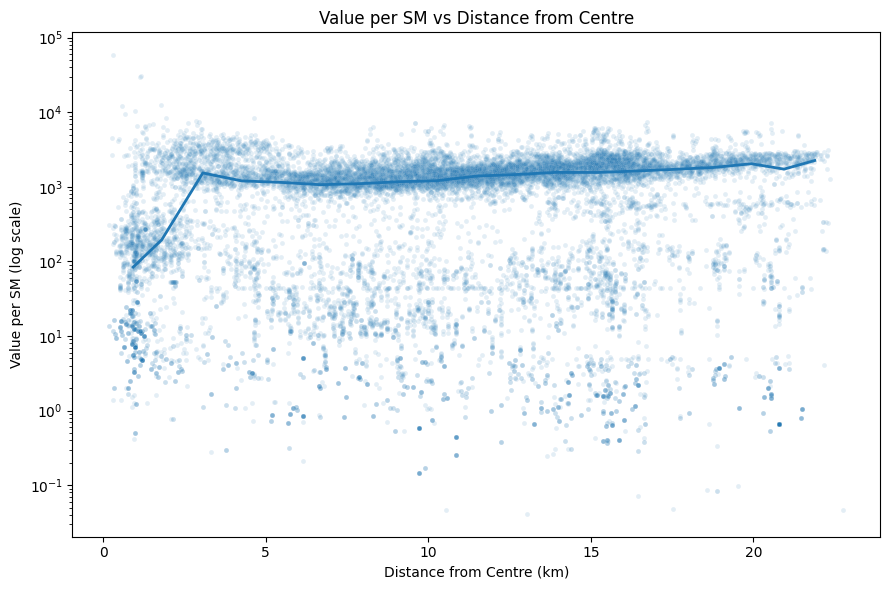

In [ ]:
# Land value vs. distance from centre

df_plot = df[
    df["DIST_FROM_CENTRE_KM"].notna() &
    df["VALUE_PER_SM"].notna() &
    (df["VALUE_PER_SM"] > 0)
].copy()

df_sample = df_plot.sample(min(15000, len(df_plot)), random_state=42)

# Bin distance
df_plot["DIST_BIN"] = pd.cut(df_plot["DIST_FROM_CENTRE_KM"], bins=20)

dist_summary = (
    df_plot.groupby("DIST_BIN", observed=False)
    .agg(
        dist_mid=("DIST_FROM_CENTRE_KM", "median"),
        median_vpsm=("VALUE_PER_SM", "median"),
        count=("VALUE_PER_SM", "size")
    )
    .dropna()
)

dist_summary = dist_summary[dist_summary["count"] >= 20]

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_sample,
    x="DIST_FROM_CENTRE_KM",
    y="VALUE_PER_SM",
    alpha=0.12,
    s=12
)

sns.lineplot(
    data=dist_summary,
    x="dist_mid",
    y="median_vpsm",
    linewidth=2
)

plt.yscale("log")
plt.xlabel("Distance from Centre (km)")
plt.ylabel("Value per SM (log scale)")
plt.title("Value per SM vs Distance from Centre")
plt.tight_layout()
plt.show()

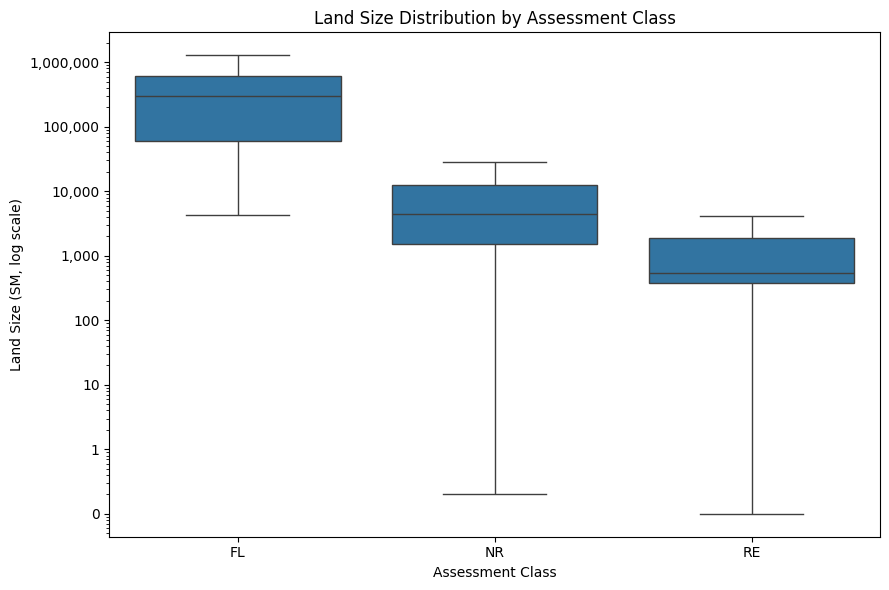

In [ ]:
# Land size by assessment class

df_plot = df[
    df["LAND_SIZE_SM"].notna() &
    df["ASSESSMENT_CLASS"].notna() &
    (df["LAND_SIZE_SM"] > 0)
].copy()

class_order = (
    df_plot.groupby("ASSESSMENT_CLASS")["LAND_SIZE_SM"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_plot,
    x="ASSESSMENT_CLASS",
    y="LAND_SIZE_SM",
    order=class_order,
    showfliers=False
)

plt.yscale("log")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Assessment Class")
plt.ylabel("Land Size (SM, log scale)")
plt.title("Land Size Distribution by Assessment Class")
plt.tight_layout()
plt.show()

In [ ]:
# Five biggest and smallest gross assessed values
pd.concat([
    df.nlargest(5, "ASSESSED_VALUE").assign(Group="Top 5"),
    df.nsmallest(5, "ASSESSED_VALUE").assign(Group="Bottom 5")
]).style.format({
    "ASSESSED_VALUE": "{:,.0f}",
    "LAND_SIZE_SM": "{:,.0f}",
    "VALUE_PER_SM": "{:,.2f}"
})

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,COMM_CODE,YEAR_OF_CONSTRUCTION,PROPERTY_TYPE,LAND_SIZE_SM,CPID,VALUE_PER_SM,center_longitude,center_latitude,AGE_OF_PROPERTY,DIST_FROM_CENTRE_KM,CITY_AREA,COMM_PROPERTY_COUNT,Group
520626,2025,201443785,4448 FRONT ST SE,"1,546,730,000",NR,SET,2007.000000,LI,"132,600",96146224,"11,664.63",-113.952732,50.882073,18.000000,19.916239,SE,1002,Top 5
687610,2025,202743258,6455 MACLEOD TR SW,"1,043,240,000",NR,MEA,1973.000000,LI,"214,924",960646680,"4,854.00",-114.074471,50.997369,52.000000,5.266005,SW,53,Top 5
682252,2025,202694972,2500 UNIVERSITY DR NW,"853,880,000",NR,UOC,1921.000000,LI,"893,070",960646089,956.12,-114.130657,51.078108,104.000000,5.537257,NW,7,Top 5
424302,2025,200589109,1301 16 AV NW,"567,150,000",NR,HIL,1900.000000,LI,"314,848",96100493,"1,801.35",-114.090196,51.063480,125.000000,2.448638,CENTRAL,713,Top 5
695205,2025,202822375,3330 HOSPITAL DR NW,"518,740,000",NR,STA,1971.000000,LI,"61,600",960650325,"8,421.10",-114.134769,51.066419,54.000000,5.014101,NW,108,Top 5
765256,2025,646004200,8012 74 AV SE,70,FL,GPI,2000.000000,LO,"45,810",380523450,0.00,-113.923275,50.990459,25.000000,12.019217,SE,27,Bottom 5
379175,2025,200182806,1 TUSCANY GLEN RD NW,120,NR,TUS,2006.500000,LO,24,96082671,4.90,-114.249273,51.118362,18.500000,14.852903,NW,1468,Bottom 5
556565,2025,201724770,3 CRANBROOK WY SE,120,NR,CRA,2010.000000,LO,26,960581901,4.60,-113.982717,50.870217,15.000000,20.382396,SE,1833,Bottom 5
739958,2025,445031701,1348 COUNTRY HILLS BV NW,130,NR,PAN,2011.000000,LO,27,380505796,4.85,-114.088111,51.145104,14.000000,11.221670,NW,1859,Bottom 5
465583,2025,200979110,235 AUBURN SOUND VW SE,140,NR,AUB,2000.000000,LO,30,96125010,4.67,-113.966269,50.889624,25.000000,18.763234,SE,1404,Bottom 5


In [ ]:
# Largest 5 properties
df.nlargest(5, "LAND_SIZE_SM") \
    .style.format({"LAND_SIZE_SM": "{:,.0f}"})

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,COMM_CODE,YEAR_OF_CONSTRUCTION,PROPERTY_TYPE,LAND_SIZE_SM,CPID,VALUE_PER_SM,center_longitude,center_latitude,AGE_OF_PROPERTY,DIST_FROM_CENTRE_KM,CITY_AREA,COMM_PROPERTY_COUNT
486255,2025,201162070,9595R 149 ST NW,407620000.000000,NR,HSN,1962.000000,LO,"13,342,400",96136613,30.550726,-114.310022,51.135803,63.000000,19.473054,NW,296
536097,2025,201568060,6465 14 ST NW,209490000.000000,NR,NPK,1979.000000,LO,"10,883,151",96149761,19.249020,-114.108972,51.110895,46.000000,7.802920,NW,2
572630,2025,201862802,11808 69 ST NW,83340000.000000,NR,02F,2012.000000,LI,"2,568,127",960603086,32.451666,-114.164815,51.168438,13.000000,15.211538,NW,5
572631,2025,201862802,11808 69 ST NW,83340000.000000,NR,02F,2012.000000,LI,"2,568,127",960630623,32.451666,-114.175078,51.160338,13.000000,14.738994,NW,5
485653,2025,201156932,9950 100 ST SE,76500.000000,FL,12A,2000.000000,LO,"1,698,223",96133672,0.045047,-113.877735,50.958905,25.000000,16.601407,SE,74


Again these seem legitimate - parks, waste facilities etc.

In [ ]:
# Largest value per SMs
df.nlargest(5, "VALUE_PER_SM") \
    .style.format({"VALUE_PER_SM": "{:,.2f}"})

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,COMM_CODE,YEAR_OF_CONSTRUCTION,PROPERTY_TYPE,LAND_SIZE_SM,CPID,VALUE_PER_SM,center_longitude,center_latitude,AGE_OF_PROPERTY,DIST_FROM_CENTRE_KM,CITY_AREA,COMM_PROPERTY_COUNT
71258,2025,39000153,4627R 53 ST NW,380500.000000,NR,VAR,1975.000000,LO,0.200000,930543681,"1,902,500.00",-114.167237,51.094985,50.000000,8.696957,NW,1176
71259,2025,39000153,4627R 53 ST NW,380500.000000,NR,VAR,1975.000000,LO,0.200000,960543684,"1,902,500.00",-114.168662,51.093157,50.000000,8.645472,NW,1176
183560,2025,79124418,2715 ERLTON ST SW,123000.000000,RE,ERL,1976.000000,LI,0.100000,860156450,"1,230,000.00",-114.062865,51.027713,49.000000,1.991711,CENTRAL,226
700574,2025,202891214,850 11 ST SW,106840000.000000,RE,DNW,2015.000000,LI,529.200000,960616839,"201,889.64",-114.088105,51.045620,10.000000,1.137501,CENTRAL,606
400790,2025,200382109,203 403 31 AV NE,469500.000000,RE,WIN,2004.000000,LI,2.800000,96098462,"167,678.57",-114.054372,51.080320,21.000000,4.145888,NE,317


Some suspicious, some are legitimate e.g high rise apartment buildings.

/tmp/ipykernel_3346/2481099067.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby("CITY_AREA")["VALUE_PER_SM"]
/tmp/ipykernel_3346/2481099067.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


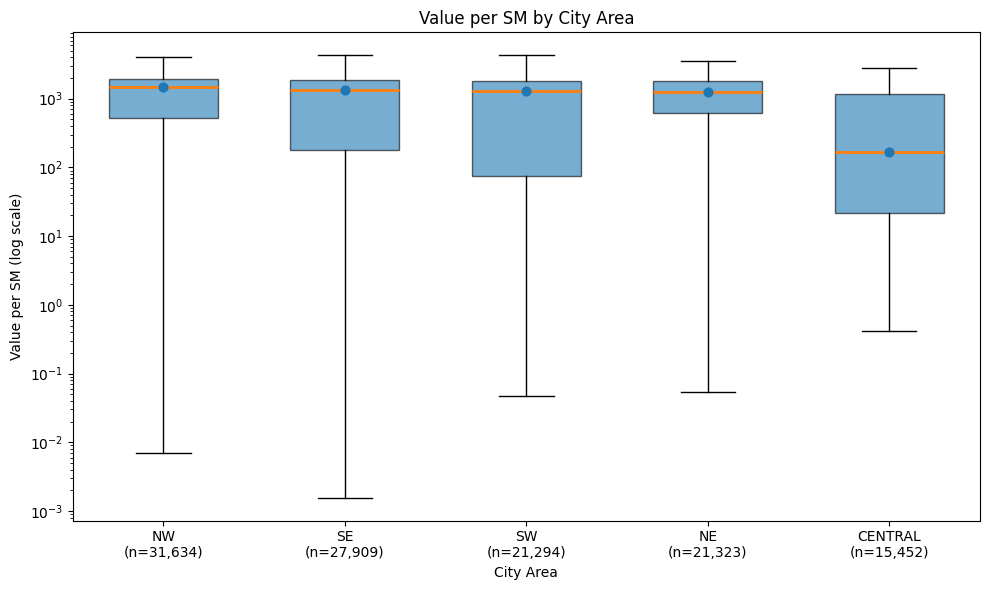

In [ ]:
# Values by city region

df_plot = df[
    df["CITY_AREA"].notna() &
    df["VALUE_PER_SM"].notna() &
    (df["VALUE_PER_SM"] > 0)
].copy()

# order areas by median value per SM
area_order = (
    df_plot.groupby("CITY_AREA")["VALUE_PER_SM"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# sample size per area
area_counts = df_plot["CITY_AREA"].value_counts()

# data in chosen order
data_to_plot = [
    df_plot.loc[df_plot["CITY_AREA"] == area, "VALUE_PER_SM"]
    for area in area_order
]

# labels with counts
labels = [f"{area}\n(n={area_counts[area]:,})" for area in area_order]

plt.figure(figsize=(10, 6))

bp = plt.boxplot(
    data_to_plot,
    labels=labels,
    patch_artist=True,
    showfliers=False,
    widths=0.6
)

# style
for box in bp["boxes"]:
    box.set_alpha(0.6)

for median in bp["medians"]:
    median.set_linewidth(2)

# overlay medians as points
medians = [vals.median() for vals in data_to_plot]
plt.scatter(range(1, len(medians) + 1), medians, s=40, zorder=3)

plt.yscale("log")
plt.ylabel("Value per SM (log scale)")
plt.xlabel("City Area")
plt.title("Value per SM by City Area")
plt.tight_layout()
plt.show()

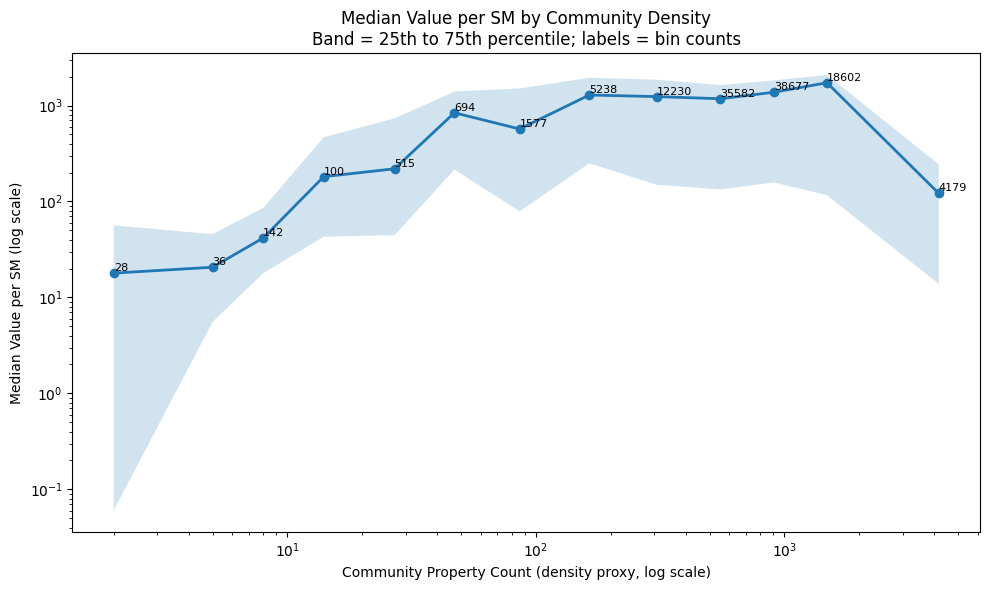

In [ ]:
# Values against density with uncertainty band

df_plot = df[
    (df["COMM_PROPERTY_COUNT"] > 0) &
    (df["VALUE_PER_SM"] > 0)
].dropna(subset=["COMM_PROPERTY_COUNT", "VALUE_PER_SM"]).copy()

bins = np.logspace(
    np.log10(df_plot["COMM_PROPERTY_COUNT"].min()),
    np.log10(df_plot["COMM_PROPERTY_COUNT"].max()),
    15
)

density_summary = (
    df_plot
    .assign(DENSITY_BIN=pd.cut(df_plot["COMM_PROPERTY_COUNT"], bins=bins))
    .groupby("DENSITY_BIN", observed=False)
    .agg(
        density_mid=("COMM_PROPERTY_COUNT", "median"),
        median_vpsm=("VALUE_PER_SM", "median"),
        q25_vpsm=("VALUE_PER_SM", lambda x: x.quantile(0.25)),
        q75_vpsm=("VALUE_PER_SM", lambda x: x.quantile(0.75)),
        count=("VALUE_PER_SM", "size")
    )
    .query("count >= 20")
    .dropna()
)

plt.figure(figsize=(10, 6))

plt.plot(
    density_summary["density_mid"],
    density_summary["median_vpsm"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    density_summary["density_mid"],
    density_summary["q25_vpsm"],
    density_summary["q75_vpsm"],
    alpha=0.2
)

for _, row in density_summary.iterrows():
    plt.text(
        row["density_mid"],
        row["median_vpsm"],
        str(int(row["count"])),
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Community Property Count (density proxy, log scale)")
plt.ylabel("Median Value per SM (log scale)")
plt.title("Median Value per SM by Community Density\nBand = 25th to 75th percentile; labels = bin counts")
plt.tight_layout()
plt.show()

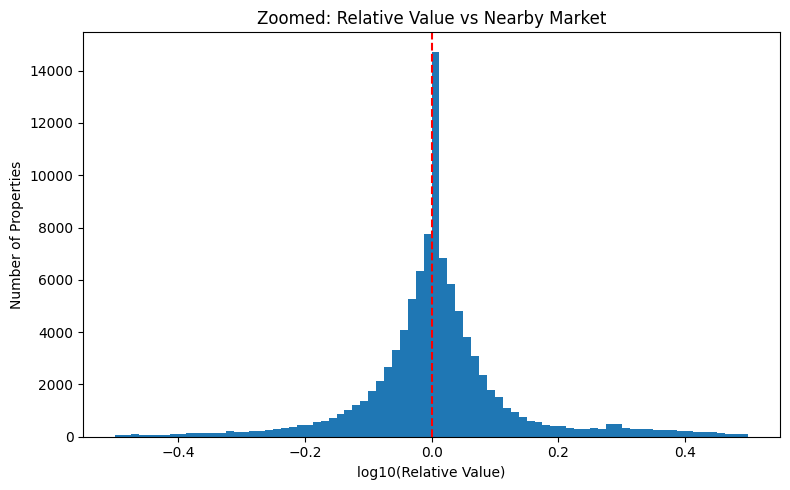

In [ ]:
# Value per SM vs. value of 10 nearest properties
plot_df = pd.concat([df_train, df_val, df_test], ignore_index=True).copy()

plot_df = plot_df[
    plot_df["VALUE_PER_SM"].notna() &
    plot_df["NEARBY_MEDIAN_VALUE_PER_SM"].notna() &
    (plot_df["VALUE_PER_SM"] > 0) &
    (plot_df["NEARBY_MEDIAN_VALUE_PER_SM"] > 0)
].copy()

plot_df["RELATIVE_VALUE"] = (
    plot_df["VALUE_PER_SM"] / plot_df["NEARBY_MEDIAN_VALUE_PER_SM"]
)

plot_df = plot_df[plot_df["RELATIVE_VALUE"] > 0].copy()
plot_df["LOG_RELATIVE_VALUE"] = np.log10(plot_df["RELATIVE_VALUE"])

subset = plot_df[
    (plot_df["LOG_RELATIVE_VALUE"] > -0.5) &
    (plot_df["LOG_RELATIVE_VALUE"] < 0.5)
].copy()

plt.figure(figsize=(8, 5))
plt.hist(subset["LOG_RELATIVE_VALUE"], bins=80)

plt.axvline(0, color="red", linestyle="--")
plt.xlabel("log10(Relative Value)")
plt.ylabel("Number of Properties")
plt.title("Zoomed: Relative Value vs Nearby Market")
plt.tight_layout()
plt.show()

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94089 entries, 431645 to 112158
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   ROLL_YEAR                   94089 non-null  int64   
 1   ROLL_NUMBER                 94089 non-null  int64   
 2   ADDRESS                     94089 non-null  string  
 3   ASSESSED_VALUE              94089 non-null  float64 
 4   ASSESSMENT_CLASS            94089 non-null  object  
 5   COMM_CODE                   94089 non-null  string  
 6   YEAR_OF_CONSTRUCTION        94089 non-null  float64 
 7   PROPERTY_TYPE               94089 non-null  string  
 8   LAND_SIZE_SM                94089 non-null  float64 
 9   CPID                        94089 non-null  string  
 10  VALUE_PER_SM                94089 non-null  float64 
 11  center_longitude            94089 non-null  float64 
 12  center_latitude             94089 non-null  float64 
 13  AGE_OF_PROPERTY

# Baseline regression models

Including land size as a predictor for value per square metre introduces a mechanical relationship, because land size is part of the target’s construction.

In [ ]:
# Regression with nearby_values features

train_df = df_train.copy()
val_df = df_val.copy()

train_df["LOG_COMM_PROPERTY_COUNT"] = np.log(train_df["COMM_PROPERTY_COUNT"])
val_df["LOG_COMM_PROPERTY_COUNT"] = np.log(val_df["COMM_PROPERTY_COUNT"])

train_df["LOG_NEARBY_MEDIAN_VALUE_PER_SM"] = np.log(train_df["NEARBY_MEDIAN_VALUE_PER_SM"])
val_df["LOG_NEARBY_MEDIAN_VALUE_PER_SM"] = np.log(val_df["NEARBY_MEDIAN_VALUE_PER_SM"])

train_df["LOG_VALUE_PER_SM"] = np.log(train_df["VALUE_PER_SM"])
val_df["LOG_VALUE_PER_SM"] = np.log(val_df["VALUE_PER_SM"])

# -----------------------------
# 1) X and y
# -----------------------------
model_features = [
    "AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "LOG_COMM_PROPERTY_COUNT",
    "LOG_NEARBY_MEDIAN_VALUE_PER_SM",
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]

X_train = train_df[model_features]
y_train = train_df["LOG_VALUE_PER_SM"]

X_val = val_df[model_features]
y_val = val_df["LOG_VALUE_PER_SM"]

# -----------------------------
# 2) Numeric / categorical columns
# -----------------------------
numeric_features = [
    "AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "LOG_COMM_PROPERTY_COUNT",
    "LOG_NEARBY_MEDIAN_VALUE_PER_SM"
]

categorical_features = [
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]

# -----------------------------
# 3) Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -----------------------------
# 4) Alpha grid
# -----------------------------
alphas = np.logspace(-4, 1, 20)

# -----------------------------
# 5) Ridge CV (L2)
# -----------------------------
ridge_cv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge_cv_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_cv_model.predict(X_train)
y_val_pred_ridge = ridge_cv_model.predict(X_val)

print("RIDGE CV (L2)")
print("Best alpha:", ridge_cv_model.named_steps["model"].alpha_)
print("Train R-squared:", r2_score(y_train, y_train_pred_ridge))
print("Validation R-squared:", r2_score(y_val, y_val_pred_ridge))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_ridge)))
print()

# -----------------------------
# 6) Lasso CV (L1)
# -----------------------------
lasso_cv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LassoCV(
        alphas=alphas,
        cv=5,
        max_iter=20000,
        random_state=42
    ))
])

lasso_cv_model.fit(X_train, y_train)

y_train_pred_lasso = lasso_cv_model.predict(X_train)
y_val_pred_lasso = lasso_cv_model.predict(X_val)

print("LASSO CV (L1)")
print("Best alpha:", lasso_cv_model.named_steps["model"].alpha_)
print("Train R-squared:", r2_score(y_train, y_train_pred_lasso))
print("Validation R-squared:", r2_score(y_val, y_val_pred_lasso))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_lasso)))

RIDGE CV (L2)
Best alpha: 0.07847599703514607
Train R-squared: 0.7418635374156684
Validation R-squared: 0.7194569033157484
Validation RMSE: 1.1930537877798668

LASSO CV (L1)
Best alpha: 0.0001
Train R-squared: 0.741844752655277
Validation R-squared: 0.7195282216700016
Validation RMSE: 1.192902131863263


In [ ]:
# -----------------------------
# Regression with nearby_values summary stats
# -----------------------------
pd.set_option("display.float_format", "{:.3f}".format)
y_train_pred_ridge = ridge_cv_model.predict(X_train)
y_val_pred_ridge = ridge_cv_model.predict(X_val)

y_train_pred_lasso = lasso_cv_model.predict(X_train)
y_val_pred_lasso = lasso_cv_model.predict(X_val)

summary_table = pd.DataFrame({
    "Model": ["Ridge (L2)", "Lasso (L1)"],
    "Best Alpha": [
        ridge_cv_model.named_steps["model"].alpha_,
        lasso_cv_model.named_steps["model"].alpha_
    ],
    "Train R-squared": [
        r2_score(y_train, y_train_pred_ridge),
        r2_score(y_train, y_train_pred_lasso)
    ],
    "Validation R-squared": [
        r2_score(y_val, y_val_pred_ridge),
        r2_score(y_val, y_val_pred_lasso)
    ],
    "Validation RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_ridge)),
        np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
    ]
})

print("MODEL SUMMARY")
print(summary_table.round(4))
print()

# -----------------------------
# 2) Feature names after preprocessing
# -----------------------------
feature_names = ridge_cv_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

# -----------------------------
# 3) Ridge coefficients in order of importance
# -----------------------------
ridge_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_cv_model.named_steps["model"].coef_
})

ridge_coefs["Importance"] = ridge_coefs["Coefficient"].abs()
ridge_coefs = ridge_coefs.sort_values("Importance", ascending=False)

print("RIDGE COEFFICIENTS (ordered by importance)")
print(ridge_coefs[["Feature", "Coefficient"]].round(4))
print()

# -----------------------------
# 4) Lasso coefficients in order of importance
# -----------------------------
lasso_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv_model.named_steps["model"].coef_
})

lasso_coefs["Importance"] = lasso_coefs["Coefficient"].abs()
lasso_coefs = lasso_coefs.sort_values("Importance", ascending=False)

print("LASSO COEFFICIENTS (ordered by importance)")
print(lasso_coefs[["Feature", "Coefficient"]].round(4))

MODEL SUMMARY
        Model  Best Alpha  Train R-squared  Validation R-squared  \
0  Ridge (L2)       0.079            0.742                 0.720   
1  Lasso (L1)       0.000            0.742                 0.720   

   Validation RMSE  
0            1.193  
1            1.193  

RIDGE COEFFICIENTS (ordered by importance)
                           Feature  Coefficient
4              ASSESSMENT_CLASS_FL       -4.483
6              ASSESSMENT_CLASS_RE        2.477
7                 PROPERTY_TYPE_IO       -2.224
5              ASSESSMENT_CLASS_NR        2.006
3   LOG_NEARBY_MEDIAN_VALUE_PER_SM        1.926
8                 PROPERTY_TYPE_LI        1.809
9                 PROPERTY_TYPE_LO        0.415
0                  AGE_OF_PROPERTY        0.046
10               CITY_AREA_CENTRAL        0.040
2          LOG_COMM_PROPERTY_COUNT       -0.038
12                    CITY_AREA_NW       -0.028
1              DIST_FROM_CENTRE_KM        0.024
11                    CITY_AREA_NE       -0.010
14

In [ ]:
# Regression without nearby_values

# -----------------------------
# 1) X and y
# -----------------------------
model_features = [
    "AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "LOG_COMM_PROPERTY_COUNT",
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]

X_train = train_df[model_features]
y_train = train_df["LOG_VALUE_PER_SM"]

X_val = val_df[model_features]
y_val = val_df["LOG_VALUE_PER_SM"]

# -----------------------------
# 2) Numeric / categorical columns
# -----------------------------
numeric_features = [
    "AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "LOG_COMM_PROPERTY_COUNT",
]

categorical_features = [
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]

# -----------------------------
# 3) Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -----------------------------
# 4) Alpha grid
# -----------------------------
alphas = np.logspace(-4, 1, 20)

# -----------------------------
# 5) Ridge CV (L2)
# -----------------------------
ridge_cv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge_cv_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_cv_model.predict(X_train)
y_val_pred_ridge = ridge_cv_model.predict(X_val)

print("RIDGE CV (L2)")
print("Best alpha:", ridge_cv_model.named_steps["model"].alpha_)
print("Train R-squared:", r2_score(y_train, y_train_pred_ridge))
print("Validation R-squared:", r2_score(y_val, y_val_pred_ridge))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_ridge)))
print()

# -----------------------------
# 6) Lasso CV (L1)
# -----------------------------
lasso_cv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LassoCV(
        alphas=alphas,
        cv=5,
        max_iter=20000,
        random_state=42
    ))
])

lasso_cv_model.fit(X_train, y_train)

y_train_pred_lasso = lasso_cv_model.predict(X_train)
y_val_pred_lasso = lasso_cv_model.predict(X_val)

print("LASSO CV (L1)")
print("Best alpha:", lasso_cv_model.named_steps["model"].alpha_)
print("Train R-squared:", r2_score(y_train, y_train_pred_lasso))
print("Validation R-squared:", r2_score(y_val, y_val_pred_lasso))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_lasso)))

RIDGE CV (L2)
Best alpha: 0.26366508987303583
Train R-squared: 0.09908233987766246
Validation R-squared: 0.09177093656731206
Validation RMSE: 2.146633626895133

LASSO CV (L1)
Best alpha: 0.0001
Train R-squared: 0.09906378058594201
Validation R-squared: 0.09186301665268892
Validation RMSE: 2.14652480676054


In [ ]:
# -----------------------------
# Regression without nearby values summary stats
# -----------------------------
y_train_pred_ridge = ridge_cv_model.predict(X_train)
y_val_pred_ridge = ridge_cv_model.predict(X_val)

y_train_pred_lasso = lasso_cv_model.predict(X_train)
y_val_pred_lasso = lasso_cv_model.predict(X_val)

summary_table = pd.DataFrame({
    "Model": ["Ridge (L2)", "Lasso (L1)"],
    "Best Alpha": [
        ridge_cv_model.named_steps["model"].alpha_,
        lasso_cv_model.named_steps["model"].alpha_
    ],
    "Train R-squared": [
        r2_score(y_train, y_train_pred_ridge),
        r2_score(y_train, y_train_pred_lasso)
    ],
    "Validation R-squared": [
        r2_score(y_val, y_val_pred_ridge),
        r2_score(y_val, y_val_pred_lasso)
    ],
    "Validation RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_ridge)),
        np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
    ]
})

print("MODEL SUMMARY")
print(summary_table.round(4))
print()

# -----------------------------
# 2) Feature names after preprocessing
# -----------------------------
feature_names = ridge_cv_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

# -----------------------------
# 3) Ridge coefficients in order of importance
# -----------------------------
ridge_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_cv_model.named_steps["model"].coef_
})

ridge_coefs["Importance"] = ridge_coefs["Coefficient"].abs()
ridge_coefs = ridge_coefs.sort_values("Importance", ascending=False)

print("RIDGE COEFFICIENTS (ordered by importance)")
print(ridge_coefs[["Feature", "Coefficient"]].round(4))
print()

# -----------------------------
# 4) Lasso coefficients in order of importance
# -----------------------------
lasso_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv_model.named_steps["model"].coef_
})

lasso_coefs["Importance"] = lasso_coefs["Coefficient"].abs()
lasso_coefs = lasso_coefs.sort_values("Importance", ascending=False)

print("LASSO COEFFICIENTS (ordered by importance)")
print(lasso_coefs[["Feature", "Coefficient"]].round(4))

MODEL SUMMARY
        Model  Best Alpha  Train R-squared  Validation R-squared  \
0  Ridge (L2)       0.264            0.099                 0.092   
1  Lasso (L1)       0.000            0.099                 0.092   

   Validation RMSE  
0            2.147  
1            2.147  

RIDGE COEFFICIENTS (ordered by importance)
                    Feature  Coefficient
3       ASSESSMENT_CLASS_FL       -5.717
5       ASSESSMENT_CLASS_RE        3.328
4       ASSESSMENT_CLASS_NR        2.389
6          PROPERTY_TYPE_IO       -2.062
7          PROPERTY_TYPE_LI        1.407
8          PROPERTY_TYPE_LO        0.655
1       DIST_FROM_CENTRE_KM        0.583
0           AGE_OF_PROPERTY        0.485
10             CITY_AREA_NE        0.282
11             CITY_AREA_NW        0.240
12             CITY_AREA_SE       -0.223
2   LOG_COMM_PROPERTY_COUNT       -0.161
9         CITY_AREA_CENTRAL       -0.158
13             CITY_AREA_SW       -0.141

LASSO COEFFICIENTS (ordered by importance)
               

# K nearest neighbour model

KNN is a distance based model - rather than feeding geographical engineered features such as city quadrant, distance from centre, density - just fed it latitude and longitudes

KNN RESULTS BY k
    k  Train R-squared  Validation R-squared  Train RMSE (log scale)  \
1   5            0.887                 0.832                   0.764   
2  10            0.897                 0.831                   0.731   
0   3            0.874                 0.825                   0.807   
3  15            0.900                 0.825                   0.720   
4  25            0.901                 0.813                   0.713   
5  35            0.902                 0.801                   0.711   
6  50            0.902                 0.788                   0.710   

   Validation RMSE (log scale)  Validation RMSE (original scale)  
1                        0.923                           673.199  
2                        0.926                           699.910  
0                        0.941                           872.144  
3                        0.942                           728.163  
4                        0.973                           781.285  
5   

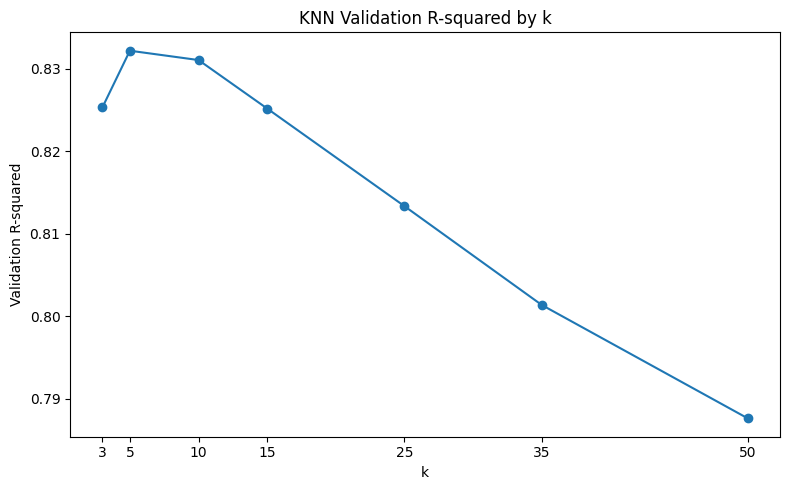

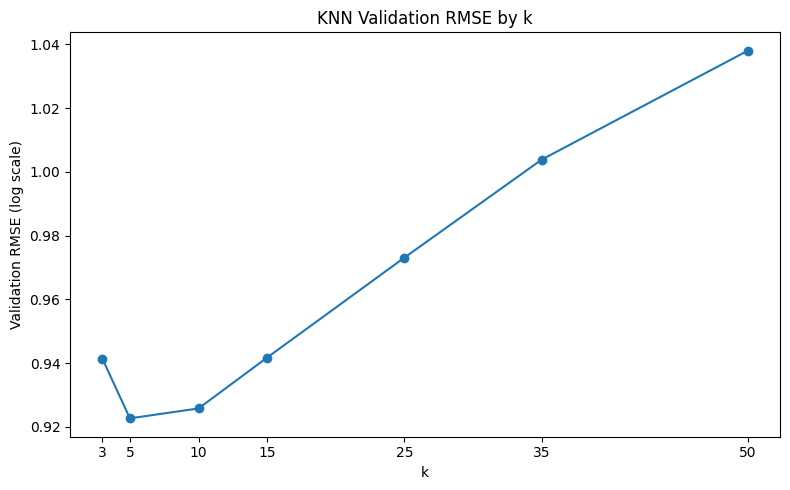


Best k: 5


In [ ]:
# K NEAREST NEIGHBOUR

# -----------------------------
# 1) Select features
# -----------------------------
features = [
    "AGE_OF_PROPERTY",
    "center_latitude",
    "center_longitude",
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
]

target = "VALUE_PER_SM"

train_df = df_train[features + [target]].copy()
val_df = df_val[features + [target]].copy()

# Keep only positive target for log transform
train_df = train_df[train_df[target] > 0].copy()
val_df = val_df[val_df[target] > 0].copy()

# Log target
train_df["LOG_VALUE_PER_SM"] = np.log(train_df[target])
val_df["LOG_VALUE_PER_SM"] = np.log(val_df[target])

X_train = train_df[features]
y_train = train_df["LOG_VALUE_PER_SM"]

X_val = val_df[features]
y_val = val_df["LOG_VALUE_PER_SM"]

# -----------------------------
# 2) Define numeric / categorical columns
# -----------------------------
numeric_features = [
    "AGE_OF_PROPERTY",
    "center_latitude",
    "center_longitude"
]

categorical_features = [
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
]

# -----------------------------
# 3) Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -----------------------------
# 4) Try different k values
# -----------------------------
k_values = [3, 5, 10, 15, 25, 35, 50]
results = []
fitted_models = {}

for k in k_values:
    knn_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=k, weights="distance"))
    ])

    knn_model.fit(X_train, y_train)

    y_train_pred = knn_model.predict(X_train)
    y_val_pred = knn_model.predict(X_val)

    results.append({
        "k": k,
        "Train R-squared": r2_score(y_train, y_train_pred),
        "Validation R-squared": r2_score(y_val, y_val_pred),
        "Train RMSE (log scale)": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Validation RMSE (log scale)": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "Validation RMSE (original scale)": np.sqrt(
            mean_squared_error(np.exp(y_val), np.exp(y_val_pred))
        )
    })

    fitted_models[k] = knn_model

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Validation R-squared", ascending=False)

print("KNN RESULTS BY k")
print(results_df.round(4))

# -----------------------------
# 5) Plot performance across k
# -----------------------------
plot_df = results_df.sort_values("k")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["k"], plot_df["Validation R-squared"], marker="o")
plt.xlabel("k")
plt.ylabel("Validation R-squared")
plt.title("KNN Validation R-squared by k")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(plot_df["k"], plot_df["Validation RMSE (log scale)"], marker="o")
plt.xlabel("k")
plt.ylabel("Validation RMSE (log scale)")
plt.title("KNN Validation RMSE by k")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Refit / retrieve best model
# -----------------------------
best_k = int(results_df.iloc[0]["k"])
best_knn_model = fitted_models[best_k]

print("\nBest k:", best_k)

In [ ]:
# -----------------------------
# 7) Summary stats for best model
# -----------------------------
y_train_pred_best = best_knn_model.predict(X_train)
y_val_pred_best = best_knn_model.predict(X_val)

knn_summary = pd.DataFrame({
    "Model": ["KNN Regressor"],
    "Best k": [best_k],
    "Weights": ["distance"],
    "Train R-squared": [r2_score(y_train, y_train_pred_best)],
    "Validation R-squared": [r2_score(y_val, y_val_pred_best)],
    "Train RMSE (log scale)": [np.sqrt(mean_squared_error(y_train, y_train_pred_best))],
    "Validation RMSE (log scale)": [np.sqrt(mean_squared_error(y_val, y_val_pred_best))],
    "Train RMSE (original scale)": [
        np.sqrt(mean_squared_error(np.exp(y_train), np.exp(y_train_pred_best)))
    ],
    "Validation RMSE (original scale)": [
        np.sqrt(mean_squared_error(np.exp(y_val), np.exp(y_val_pred_best)))
    ]
})

print("\nBEST KNN MODEL SUMMARY")
print(knn_summary.round(4))


BEST KNN MODEL SUMMARY
           Model  Best k   Weights  Train R-squared  Validation R-squared  \
0  KNN Regressor       5  distance            0.887                 0.832   

   Train RMSE (log scale)  Validation RMSE (log scale)  \
0                   0.764                        0.923   

   Train RMSE (original scale)  Validation RMSE (original scale)  
0                      122.118                           673.199  


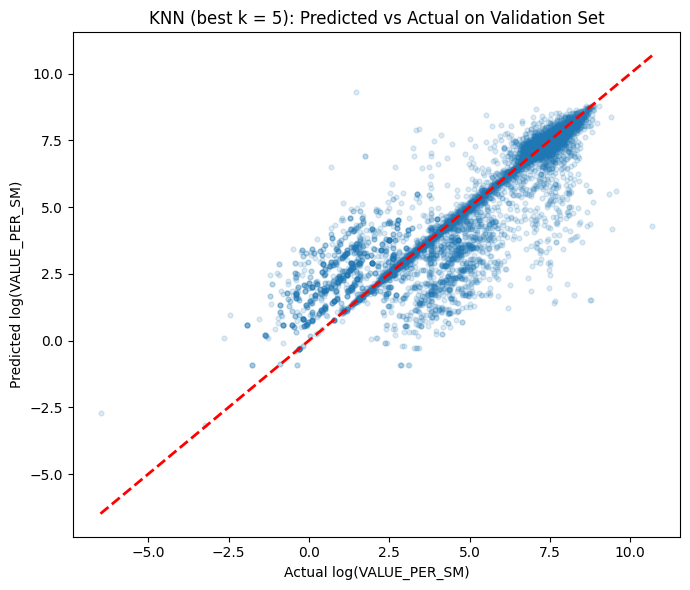

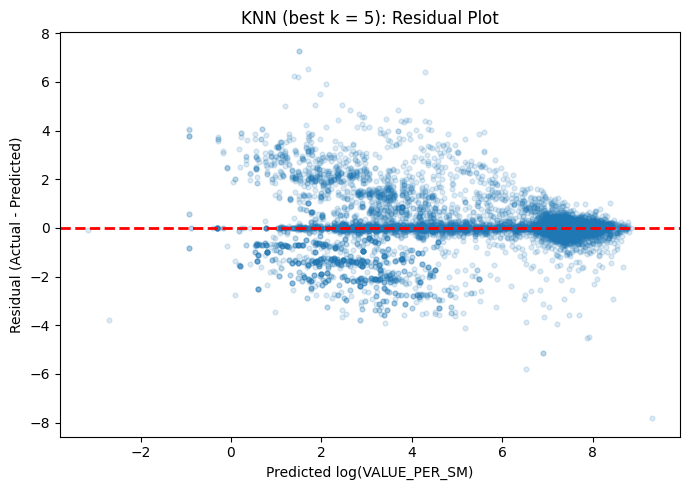

In [ ]:
# Use the best KNN model for diagnostic plots
y_val_pred = best_knn_model.predict(X_val)

# Predicted vs Actual
plt.figure(figsize=(7, 6))
plt.scatter(y_val, y_val_pred, alpha=0.15, s=12)

min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.xlabel("Actual log(VALUE_PER_SM)")
plt.ylabel("Predicted log(VALUE_PER_SM)")
plt.title(f"KNN (best k = {best_k}): Predicted vs Actual on Validation Set")
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_val - y_val_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_val_pred, residuals, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted log(VALUE_PER_SM)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"KNN (best k = {best_k}): Residual Plot")
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 8) Permutation importance for best model
# -----------------------------
perm_result = permutation_importance(
    best_knn_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values("Importance", ascending=False)

print("\nBEST KNN FEATURE IMPORTANCE")
print(importance_df.round(4))


BEST KNN FEATURE IMPORTANCE
            Feature  Importance   Std
1   center_latitude       1.185 0.009
2  center_longitude       1.183 0.012
0   AGE_OF_PROPERTY       1.107 0.013
3  ASSESSMENT_CLASS       0.079 0.004
4     PROPERTY_TYPE       0.060 0.002
